<a href="https://colab.research.google.com/github/mimomaina/Career-Path-Recommendation-System/blob/main/(Embeddings)_Career_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Dataset

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/cleaned_job_data.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292167 entries, 0 to 292166
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Job Title         292167 non-null  object
 1   Job Description   292167 non-null  object
 2   Responsibilities  292167 non-null  object
 3   skills            292167 non-null  object
 4   combined_text     292167 non-null  object
 5   Cleaned Skills    292167 non-null  object
 6   Refined Skills    292167 non-null  object
 7   Final Skills      292167 non-null  object
dtypes: object(8)
memory usage: 17.8+ MB


# Sentence Transformer

In [ ]:
# pip install sentence-transformers


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np


In [ ]:
job_texts = df["combined_text"].tolist()

# Load SBERT model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Set optimal batch size for CPU
batch_size = 128  # Adjust based on available memory

# Generate embeddings (CPU-based, since TPU isn't optimized)
job_embeddings = model.encode(job_texts,
                              batch_size=batch_size,
                              show_progress_bar=True)

# Convert to NumPy array
job_embeddings = np.array(job_embeddings)

# Save embeddings
np.save("job_embeddings.npy", job_embeddings)

# Save dataset with embedding references
df["Embedding Index"] = range(len(df))
df.to_csv("cleaned_job_data_with_index.csv", index=False)

print(f"Embeddings Shape: {job_embeddings.shape}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2283 [00:00<?, ?it/s]

Embeddings Shape: (292167, 384)


In [ ]:
# job_texts = df["combined_text"].tolist()
# # Load SBERT model
# model = SentenceTransformer("all-MiniLM-L6-v2")

# # Optimize batch size for TPU
# batch_size = 1024  # Try 512 or 1024 based on TPU limits

# # Generate embeddings using optimized settings
# job_embeddings = model.encode(job_texts,
#                               batch_size=batch_size,
#                               device='cuda',  # Forces TPU usage
#                               multi_process=True,  # Enables parallelization
#                               show_progress_bar=True)

# # Convert to NumPy array
# job_embeddings = np.array(job_embeddings)

# # Save embeddings
# np.save("job_embeddings.npy", job_embeddings)

# # Save dataset with embedding references
# df["Embedding Index"] = range(len(df))
# df.to_csv("cleaned_job_data_with_index.csv", index=False)

# print(f"Embeddings Shape: {job_embeddings.shape}")

In [ ]:
# # Load the SBERT model
# model = SentenceTransformer("all-MiniLM-L6-v2")

# # Generate embeddings for job descriptions
# df["Embeddings"] = df["combined_text"].apply(lambda x: model.encode(x))

# # Convert embeddings to a NumPy array
# job_embeddings = np.vstack(df["Embeddings"].values)

# # Save embeddings for later use
# np.save("job_embeddings.npy", job_embeddings)

# print("SBERT embeddings generated and saved successfully")


# Visual Evaluation for Transformer

1.Visualizing Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Choose a random job description
random_idx = 10  # Change this number to test different jobs
query_embedding = job_embeddings[random_idx].reshape(1, -1)

# Compute similarity with all job embeddings
similarities = cosine_similarity(query_embedding, job_embeddings).flatten()

# Get top 5 most similar jobs (excluding itself)
top_indices = similarities.argsort()[-6:-1][::-1]

print("\n**Query Job:**", df.iloc[random_idx]["Job Title"])
print("\n**Most Similar Jobs:**")
for idx in top_indices:
    print(f"{df.iloc[idx]['Job Title']} (Similarity: {similarities[idx]:.3f})")



**Query Job:** Database Administrator

**Most Similar Jobs:**
Database Administrator (Similarity: 1.000)
Database Administrator (Similarity: 1.000)
Database Administrator (Similarity: 1.000)
Database Administrator (Similarity: 1.000)
Database Administrator (Similarity: 1.000)


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Pick a random job index (excluding the first 10 to avoid common ones)
random_idx = np.random.randint(10, len(df))

# Get query job embedding
query_embedding = job_embeddings[random_idx].reshape(1, -1)

# Compute similarity with all job embeddings
similarities = cosine_similarity(query_embedding, job_embeddings).flatten()

# Get top 5 most similar jobs (excluding itself)
top_indices = similarities.argsort()[-6:-1][::-1]

print("\n🔍 **Query Job:**", df.iloc[random_idx]["Job Title"])
print("\n✅ **Most Similar Jobs:**")
for idx in top_indices:
    print(f"🔹 {df.iloc[idx]['Job Title']} (Similarity: {similarities[idx]:.3f})")



🔍 **Query Job:** Systems Administrator

✅ **Most Similar Jobs:**
🔹 Systems Administrator (Similarity: 1.000)
🔹 Systems Administrator (Similarity: 1.000)
🔹 Systems Administrator (Similarity: 1.000)
🔹 Systems Administrator (Similarity: 1.000)
🔹 Systems Administrator (Similarity: 1.000)


In [ ]:
(print(job_embeddings[:5]))

[[-0.03544539 -0.04393417  0.00163256 ...  0.05129791  0.08379372
   0.03315591]
 [-0.03244685  0.08065672 -0.01326823 ...  0.07145933  0.05544325
  -0.01114211]
 [-0.07477556 -0.006032   -0.08263267 ... -0.0392198   0.15537752
   0.01744128]
 [ 0.00249707  0.02465506 -0.05511649 ... -0.03140651  0.05624831
   0.02875773]
 [ 0.01470258  0.08036084 -0.04064751 ...  0.01504234  0.04006861
  -0.02056059]]


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Select two different job embeddings for testing
sim_score = cosine_similarity(job_embeddings[0].reshape(1, -1), job_embeddings[1].reshape(1, -1))

print(f" Similarity between Job 1 and Job 2: {sim_score[0][0]:.3f}")


 Similarity between Job 1 and Job 2: 0.283


In [ ]:
from sklearn.preprocessing import normalize

# Normalize embeddings before computing similarity
normalized_embeddings = normalize(job_embeddings)

# Recalculate similarity with normalized embeddings
sim_score = cosine_similarity(normalized_embeddings[0].reshape(1, -1), normalized_embeddings[1].reshape(1, -1))

print(f" Fixed Similarity Score: {sim_score[0][0]:.3f}")


 Fixed Similarity Score: 0.283


In [ ]:
import numpy as np

# Compute variance of embeddings (should NOT be close to 0)
variance = np.var(job_embeddings, axis=0)
print(f"✅ Mean Variance of Embeddings: {np.mean(variance):.6f}")


✅ Mean Variance of Embeddings: 0.001729


In [ ]:
print(df["combined_text"].sample(20))


167187    A Backend Developer is tasked with building an...
171983    A Quality Assurance Analyst tests software and...
53843     A Front-End Developer specializes in creating ...
198650    Mobile App Developers design and develop mobil...
93133     An API Developer creates and maintains applica...
57820     Mobile App Developers design and develop mobil...
49363     A Backend Developer is tasked with building an...
155086    Java Software Engineers develop and maintain s...
108876    Full-Stack Developers are skilled in both fron...
190664    An Infrastructure Manager is responsible for t...
155549    Network Administrators manage an organizations...
79608     An Infrastructure Manager is responsible for t...
177300    An Automation Tester uses automated testing to...
229138    A Business Systems Analyst analyzes business p...
188384    A Web Designer specializes in designing visual...
81738     UI/UX Front-End Developers focus on creating u...
16411     Network Security Specialists f

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292167 entries, 0 to 292166
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Job Title         292167 non-null  object
 1   Job Description   292167 non-null  object
 2   Responsibilities  292167 non-null  object
 3   skills            292167 non-null  object
 4   combined_text     292167 non-null  object
 5   Cleaned Skills    292167 non-null  object
 6   Refined Skills    292167 non-null  object
 7   Final Skills      292167 non-null  object
 8   Embedding Index   292167 non-null  int64 
dtypes: int64(1), object(8)
memory usage: 20.1+ MB


In [ ]:
# Define your own job title for testing
query_job_title = "Software Engineer"  # Change this to any job title

# Find the index of this job in the dataset
query_idx = df[df["Job Title"] == query_job_title].index[0]

# Get query job embedding
query_embedding = job_embeddings[query_idx].reshape(1, -1)

# Compute similarity
similarities = cosine_similarity(query_embedding, job_embeddings).flatten()

# Get top 5 most similar jobs (excluding itself)
top_indices = similarities.argsort()[-6:-1][::-1]

print("\n🔍 **Query Job:**", df.iloc[query_idx]["Job Title"])
print("\n✅ **Most Similar Jobs:**")
for idx in top_indices:
    print(f"🔹 {df.iloc[idx]['Job Title']} (Similarity: {similarities[idx]:.3f})")



🔍 **Query Job:** Software Engineer

✅ **Most Similar Jobs:**
🔹 Software Engineer (Similarity: 1.000)
🔹 Software Engineer (Similarity: 1.000)
🔹 Software Engineer (Similarity: 1.000)
🔹 Software Engineer (Similarity: 1.000)
🔹 Software Engineer (Similarity: 1.000)


2.Cluster Similar Jobs Using TSNE

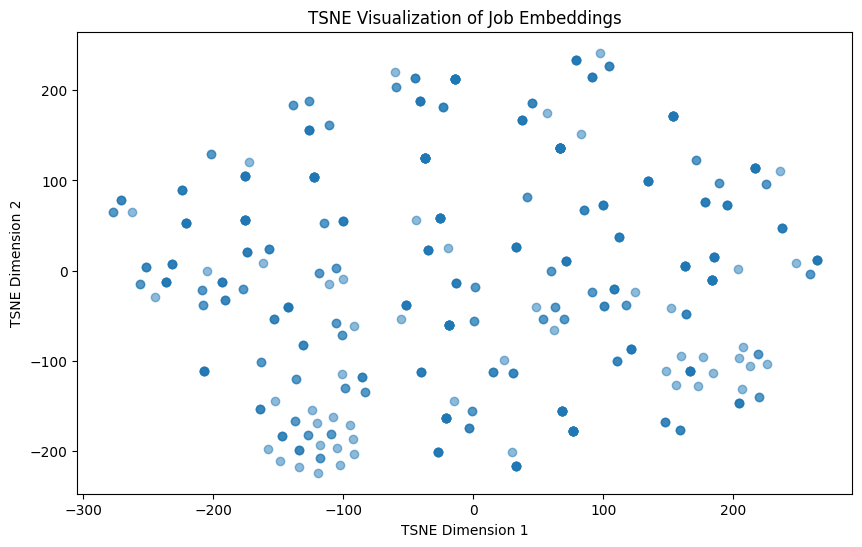

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Reduce dimensions for visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(job_embeddings[:500])  # Reduce to 500 jobs for performance

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5)
plt.title("TSNE Visualization of Job Embeddings")
plt.xlabel("TSNE Dimension 1")
plt.ylabel("TSNE Dimension 2")
plt.show()


3. Manual Verification: Comparing Text Similarity

In [ ]:
job1_idx = 10
job2_idx = 25  # Pick a different job

sim_score = cosine_similarity(job_embeddings[job1_idx].reshape(1, -1),
                              job_embeddings[job2_idx].reshape(1, -1))[0][0]

print(f"\n Comparing Jobs:\n1 {df.iloc[job1_idx]['Job Title']}\n2 {df.iloc[job2_idx]['Job Title']}")
print(f" Similarity Score: {sim_score:.3f}")



 Comparing Jobs:
1 Database Administrator
2 Data Engineer
 Similarity Score: 0.454


# 2.SBERT

In [ ]:
from sentence_transformers import SentenceTransformer

# Try a stronger model
model = SentenceTransformer("all-mpnet-base-v2")

# Regenerate embeddings
job_embeddings = model.encode(df["combined_text"].tolist(), batch_size=256, show_progress_bar=True)

# Save embeddings
np.save("job_embeddings_fixed.npy", job_embeddings)

print("New embeddings generated with all-mpnet-base-v2!")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1142 [00:00<?, ?it/s]

✅ New embeddings generated with all-mpnet-base-v2!


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Select two different job embeddings for testing
sim_score = cosine_similarity(job_embeddings[0].reshape(1, -1), job_embeddings[1].reshape(1, -1))

print(f" Similarity between Job 1 and Job 2: {sim_score[0][0]:.3f}")


 Similarity between Job 1 and Job 2: 0.337


In [ ]:
(print(job_embeddings[:5]))

[[ 0.06695115 -0.04914413 -0.07115117 ... -0.0149376   0.08897269
  -0.01941227]
 [ 0.01326747 -0.0025931  -0.02337098 ... -0.01237102  0.03239047
  -0.01270279]
 [ 0.01449226  0.02344299 -0.05839102 ... -0.01633206  0.11170624
  -0.02008205]
 [ 0.00018979 -0.04613547 -0.062334   ... -0.01162674  0.04453241
   0.00250385]
 [ 0.04693248  0.00312936 -0.00702638 ...  0.01052256  0.06771141
  -0.01318176]]


In [ ]:
# Define your own job title for testing
query_job_title = "Database Administrator"  # Change this to any job title

# Find the index of this job in the dataset
query_idx = df[df["Job Title"] == query_job_title].index[0]

# Get query job embedding
query_embedding = job_embeddings[query_idx].reshape(1, -1)

# Compute similarity
similarities = cosine_similarity(query_embedding, job_embeddings).flatten()

# Get top 5 most similar jobs (excluding itself)
top_indices = similarities.argsort()[-6:-1][::-1]

print("\n🔍 **Query Job:**", df.iloc[query_idx]["Job Title"])
print("\n✅ **Most Similar Jobs:**")
for idx in top_indices:
    print(f"🔹 {df.iloc[idx]['Job Title']} (Similarity: {similarities[idx]:.3f})")



🔍 **Query Job:** Database Administrator

✅ **Most Similar Jobs:**
🔹 Database Administrator (Similarity: 1.000)
🔹 Database Administrator (Similarity: 1.000)
🔹 Database Administrator (Similarity: 1.000)
🔹 Database Administrator (Similarity: 1.000)
🔹 Database Administrator (Similarity: 1.000)


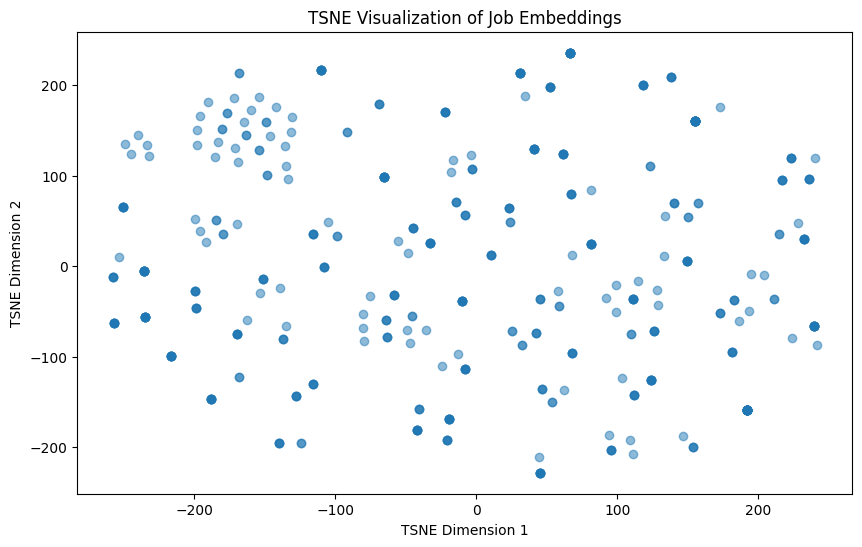

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Reduce dimensions for visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(job_embeddings[:500])  # Reduce to 500 jobs for performance

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5)
plt.title("TSNE Visualization of Job Embeddings")
plt.xlabel("TSNE Dimension 1")
plt.ylabel("TSNE Dimension 2")
plt.show()


Each dot is a job title embedding.
Clusters indicate jobs with similar embeddings, meaning they are related in some way.
Scattered points suggest jobs that are more distinct

In [ ]:
job1_idx = 10
job2_idx = 25

sim_score = cosine_similarity(job_embeddings[job1_idx].reshape(1, -1),
                              job_embeddings[job2_idx].reshape(1, -1))[0][0]

print(f"\n Comparing Jobs:\n1 {df.iloc[job1_idx]['Job Title']}\n2 {df.iloc[job2_idx]['Job Title']}")
print(f" Similarity Score: {sim_score:.3f}")



 Comparing Jobs:
1 Database Administrator
2 Data Engineer
 Similarity Score: 0.524


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

query_idx = df[df['Job Title'] == 'Software Engineer'].index[0]
query_embedding = job_embeddings[query_idx].reshape(1, -1)

similarities = cosine_similarity(query_embedding, job_embeddings)[0]
ranked_indices = np.argsort(similarities)[::-1][1:6]  # Skip self-match

for idx in ranked_indices:
    print(f"{df.iloc[idx]['Job Title']} (Similarity: {similarities[idx]:.3f})")


Software Engineer (Similarity: 1.000)
Software Engineer (Similarity: 1.000)
Software Engineer (Similarity: 1.000)
Software Engineer (Similarity: 1.000)
Software Engineer (Similarity: 1.000)


In [ ]:
print(df['Job Title'].value_counts())  # See if some jobs appear multiple times


Job Title
Software Engineer              27630
Network Engineer               24393
Software Tester                20945
Network Administrator          17581
Systems Administrator          17281
Java Developer                 10589
QA Analyst                     10516
Front-End Developer            10455
Technical Writer               10376
Web Developer                  10361
Database Administrator         10280
IT Manager                      7092
Front-End Engineer              7086
Data Analyst                    7003
Network Security Specialist     6994
Quality Assurance Analyst       6991
Back-End Developer              6982
Systems Engineer                6952
Data Scientist                  6940
Data Engineer                   6926
Web Designer                    6921
Database Developer              6908
UI Developer                    6898
Environmental Engineer          6803
IT Support Specialist           3529
Software Developer              3517
Customer Support Specialist 

# Aggregating job titles

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292167 entries, 0 to 292166
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Job Title         292167 non-null  object
 1   Job Description   292167 non-null  object
 2   Responsibilities  292167 non-null  object
 3   skills            292167 non-null  object
 4   combined_text     292167 non-null  object
 5   Cleaned Skills    292167 non-null  object
 6   Refined Skills    292167 non-null  object
 7   Final Skills      292167 non-null  object
 8   Embedding Index   292167 non-null  int64 
dtypes: int64(1), object(8)
memory usage: 20.1+ MB


In [ ]:
# Load dataset
df = pd.read_csv("/content/cleaned_job_data.csv")

# Get unique job titles
unique_jobs = df['Job Title'].unique()
unique_jobs

array(['Web Developer', 'Network Engineer', 'Software Tester',
       'QA Analyst', 'Network Administrator', 'Software Engineer',
       'UI Developer', 'Technical Writer', 'Systems Administrator',
       'Database Administrator', 'IT Support Specialist',
       'Software Developer', 'Systems Engineer', 'Database Developer',
       'Java Developer', 'Data Engineer', 'Front-End Engineer',
       'Environmental Engineer', 'Back-End Developer', 'Data Analyst',
       'Network Technician', 'IT Manager', 'Quality Assurance Analyst',
       'Front-End Developer', 'Web Designer', 'Data Scientist',
       'Network Analyst', 'Mechanical Designer',
       'Network Security Specialist', 'Customer Support Specialist',
       'Architectural Designer', 'IT Administrator', 'Systems Analyst'],
      dtype=object)

In [ ]:
# Create a new DataFrame with unique job titles
df_unique = pd.DataFrame(unique_jobs, columns=['Job Title'])

# Save this cleaned dataset for future use
df_unique.to_csv("unique_job_titles.csv", index=False)

In [ ]:
import numpy as np

# Assume job_embeddings is an array where each row corresponds to a job posting embedding
job_embeddings = np.load("job_embeddings.npy")  # Load your precomputed embeddings

# Create a mapping of job titles to indices
job_title_to_indices = df.groupby("Job Title").indices

# Compute the average embedding for each unique job title
unique_job_embeddings = {
    title: np.mean(job_embeddings[indices], axis=0)  # Average the embeddings
    for title, indices in job_title_to_indices.items()
}

# Convert back to array for similarity search
job_titles = list(unique_job_embeddings.keys())
job_embeddings_avg = np.array(list(unique_job_embeddings.values()))

# Save for future use
np.save("job_embeddings_avg.npy", job_embeddings_avg)
pd.DataFrame(job_titles, columns=["Job Title"]).to_csv("unique_job_titles.csv", index=False)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Load the saved embeddings
job_embeddings_avg = np.load("job_embeddings_avg.npy")
job_titles = pd.read_csv("unique_job_titles.csv")["Job Title"].tolist()

# Define the query job
query_title = "Software Engineer"
query_idx = job_titles.index(query_title)
query_embedding = job_embeddings_avg[query_idx].reshape(1, -1)

# Compute similarities
similarities = cosine_similarity(query_embedding, job_embeddings_avg)[0]

# Rank and get top similar jobs
ranked_indices = np.argsort(similarities)[::-1][1:6]  # Skip the exact match
for idx in ranked_indices:
    print(f" {job_titles[idx]} (Similarity: {similarities[idx]:.3f})")


 Web Developer (Similarity: 0.884)
 UI Developer (Similarity: 0.778)
 Front-End Engineer (Similarity: 0.741)
 Java Developer (Similarity: 0.703)
 Back-End Developer (Similarity: 0.700)
